# Dose Response Study

Simulating dose response experiments.

We begin by importing required packages.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.optimize as opt
import statistics
from scipy import stats
import os
import re
import ptitprince as pt #rain plots
from datetime import date

import libraries.disturbances as dt
import libraries.normalization as nrm
import libraries.dose_response as dr
import libraries.utilities as util

## Data Generation

Here you can specify the particulars of the experiment.

In [4]:
## Simulation parameters
## Ensure the appropriate PLAID layouts exist under compounds_PLAID_layouts 

concentrations = 8 #Possible to use 4, 6, 8
replicates = 3

compounds = int((14*22-20)/(concentrations*replicates))

if concentrations == 4:
    dilution = 15
elif concentrations == 6:
    dilution = 18
elif concentrations == 8:
    dilution = 8
elif concentrations == 12:
    dilution = 4
else:
    print("Please specify the dilution factor")


expected_noise = 0.01
error_l = 15 #High
#error_nl = 2 #High
#error_nl = 0.5 #High
#error_nl = 0.25 #High
#error_nl = 0.125 #High
error_nl = 0.085 #Low or medium?
#error_nl = 0.2 #right half
#error_nl = 0.4 #right half
my_min_dist = 0

In [5]:
slopes = [0.5,1,1.5,2]

#error_types = [{'type':"left", 'error_function':dt.add_exponential_errors_to_left_columns,'error_correction':nrm.normalize_plate_column_effect,'error':error_nl}]
#error_types = [{'type':"diagonal", 'error_function':dt.add_diagonal_errors,'error_correction':nrm.normalize_plate_nearest_control,'error':error_nl}]
#error_types = [{'type':"right-half", 'error_function':dt.add_errors_to_right_columns_half,'error_correction':nrm.normalize_plate_nearest_control,'error':error_nl}]
error_types = [{'type':"bowl-nl", 'error_function':dt.add_bowlshaped_errors_nl,'error_correction':nrm.normalize_plate_nearest_control,'error':error_nl}]
               #{'type':"bowl", 'error_function':dt.add_bowlshaped_errors,'error_correction':nrm.normalize_plate_nearest_control,'error':error_l}]
               #{'type':"left-nl", 'error_function':dt.add_errors_to_left_columns,'error_correction':nrm.normalize_plate_column_effect,'error':error_nl},
               #{'type':"left", 'error_function':dt.add_linear_errors_to_left_columns,'error_correction':nrm.normalize_plate_column_effect,'error':error_l},
               #{'type':"right", 'error_function':dt.add_linear_errors_to_right_columns,'error_correction':nrm.normalize_plate_column_effect,'error':error_l},
               #{'type':"top-nl", 'error_function':dt.add_errors_to_upper_rows,'error_correction':nrm.normalize_plate_row_effect,'error':error_nl},
               #{'type':"top", 'error_function':dt.add_linear_errors_to_upper_rows,'error_correction':nrm.normalize_plate_row_effect,'error':error_l},
               #{'type':"bottom", 'error_function':dt.add_linear_errors_to_lower_rows,'error_correction':nrm.normalize_plate_row_effect,'error':error_l},
               #{'type':"left-exp", 'error_function':dt.add_exponential_errors_to_left_columns,'error_correction':nrm.normalize_plate_column_effect,'error':error_nl},
               #{'type':"top-exp", 'error_function':dt.add_exponential_errors_to_upper_rows,'error_correction':nrm.normalize_plate_row_effect,'error':error_nl}]
#{'type':,error_function':,'error_correction':}


plate_types_location = [{'type':'COMPD', 'dir':'layouts/compounds_COMPD_layouts/','regex':'plate_layout_(.*)'+str(compounds)+'-'+str(concentrations)+'-'+str(replicates)+'_(0*)(.+?).npy','error_correction':nrm.normalize_plate_lowess_2d},
                        {'type':'PLAID', 'dir':'layouts/compounds_PLAID_layouts/','regex':'plate_layout_(.*)'+str(compounds)+'-'+str(concentrations)+'-'+str(replicates)+'_(0*)(.+?).npy','error_correction':nrm.normalize_plate_lowess_2d},
                        {'type':'Random','dir':'layouts/compounds_manual_layouts/','regex':'plate_layout_rand_(.+?).npy','error_correction':nrm.normalize_plate_lowess_2d}
                       ]

## Results
absolute_ic50_data = np.empty((0,7))
relative_ic50_data = np.empty((0,7))
residuals = np.empty((0,7)) #Columns: "layout", "method", "Error", "E", "R_lost", "residuals", "true_residuals"

today = (date.today()).strftime("%Y%m%d")+"-debug-reg"

absolute_ic50_data_f=open('absolute_ic50_data-'+str(compounds)+'-'+str(concentrations)+'-dil'+str(dilution)+'-'+str(replicates)+'-'+str(error_nl)+'-'+today+'.csv','a')
relative_ic50_data_f=open('relative_ic50_data-'+str(compounds)+'-'+str(concentrations)+'-dil'+str(dilution)+'-'+str(replicates)+'-'+str(error_nl)+'-'+today+'.csv','a')
residuals_f=open('residuals-'+str(compounds)+'-'+str(concentrations)+'-dil'+str(dilution)+'-'+str(replicates)+'-'+str(error_nl)+'-'+today+'.csv','a')

Now we place them on a plate, add a small random noise, apply plate effects error and correct them.

Testing e: 50
            b  c    d          e  startDose  nDose  dilution   abs IC50
compound                                                               
0         0.5  0  100  50.892285      10000      8         8  50.892285
1         1.0  0  100  53.439306      10000      8         8  53.439306
2         1.5  0  100  54.133691      10000      8         8  54.133691
3         0.5  0  100  54.482406      10000      8         8  54.482406
4         1.0  0  100  51.922846      10000      8         8  51.922846
5         1.5  0  100  54.361609      10000      8         8  54.361609
6         0.5  0  100  53.715000      10000      8         8  53.715000
7         1.0  0  100  50.313560      10000      8         8  50.313560
8         1.5  0  100  52.190695      10000      8         8  52.190695
9         0.5  0  100  51.733297      10000      8         8  51.733297
10        1.0  0  100  51.982701      10000      8         8  51.982701
11        1.5  0  100  50.703844      10000      8

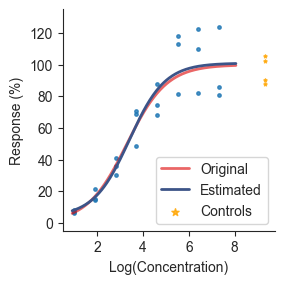


Plotting curve for compound 1
The score of this fit is: 0.9471785927280801

The original IC50 is: compound
1    53.439306
Name: e, dtype: float64

The estimated IC50 is: 57.65794987959757

The absolute log error is: compound
1    0.032998
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         1  10000.000000  1.00000   0.531552    0.632089
1         1   1250.000000  1.90309   4.099869    4.000389
2         1    156.250000  2.80618  25.484994   23.005156
3         1     19.531250  3.70927  73.234067   61.609977
4         1      2.441406  4.61236  95.631040  113.920980
5         1      0.305176  5.51545  99.432173  116.850966
6         1      0.038147  6.41854  99.928667  105.412280
7         1      0.004768  7.32163  99.991078  101.153693
0         1  10000.000000  1.00000   0.531552    0.479669
1         1   1250.000000  1.90309   4.099869    3.737887
2         1    156.250000  2.80618  25.484994   21.586020
3         1     19.531250  3.70927  73.

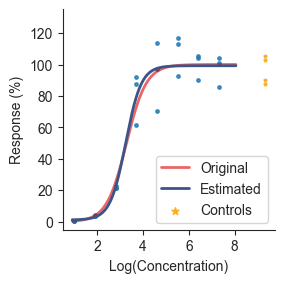


Plotting curve for compound 2
The score of this fit is: 0.9539190843698407

The original IC50 is: compound
2    54.133691
Name: e, dtype: float64

The estimated IC50 is: 63.98310903307252

The absolute log error is: compound
2    0.072598
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         2  10000.000000  1.00000   0.039813    0.047130
1         2   1250.000000  1.90309   0.893182    1.057624
2         2    156.250000  2.80618  16.938378   16.113173
3         2     19.531250  3.70927  82.188360   70.282401
4         2      2.441406  4.61236  99.051322   90.241702
5         2      0.305176  5.51545  99.957690  100.110690
6         2      0.038147  6.41854  99.998129   92.076164
7         2      0.004768  7.32163  99.999917   75.790654
0         2  10000.000000  1.00000   0.039813    0.047453
1         2   1250.000000  1.90309   0.893182    0.864948
2         2    156.250000  2.80618  16.938378   12.457192
3         2     19.531250  3.70927  82.

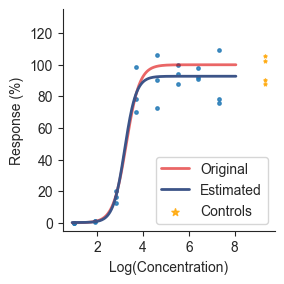


Plotting curve for compound 3
The score of this fit is: 0.9390128790944082

The original IC50 is: compound
3    54.482406
Name: e, dtype: float64

The estimated IC50 is: 33.83851297906652

The absolute log error is: compound
3    0.206845
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         3  10000.000000  1.00000   6.873846    6.404539
1         3   1250.000000  1.90309  17.271442   19.671241
2         3    156.250000  2.80618  37.126594   42.741831
3         3     19.531250  3.70927  62.549333   43.670258
4         3      2.441406  4.61236  82.529641   77.630965
5         3      0.305176  5.51545  93.036908  109.171180
6         3      0.038147  6.41854  97.422139  121.660602
7         3      0.004768  7.32163  99.073143   98.754826
0         3  10000.000000  1.00000   6.873846    6.039675
1         3   1250.000000  1.90309  17.271442   17.133096
2         3    156.250000  2.80618  37.126594   29.224039
3         3     19.531250  3.70927  62.

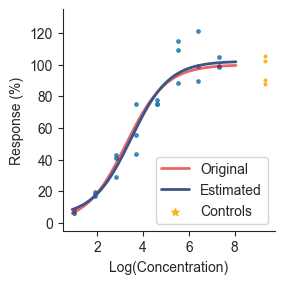


Plotting curve for compound 4
The score of this fit is: 0.9282777913258032

The original IC50 is: compound
4    51.922846
Name: e, dtype: float64

The estimated IC50 is: 53.018918799316104

The absolute log error is: compound
4    0.009072
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         4  10000.000000  1.00000   0.516546    0.420491
1         4   1250.000000  1.90309   3.988166    3.533159
2         4    156.250000  2.80618  24.942180   27.017274
3         4     19.531250  3.70927  72.666018   81.231695
4         4      2.441406  4.61236  95.509170  126.600675
5         4      0.305176  5.51545  99.415686  108.367930
6         4      0.038147  6.41854  99.926585   85.816965
7         4      0.004768  7.32163  99.990817   81.707831
0         4  10000.000000  1.00000   0.516546    0.360947
1         4   1250.000000  1.90309   3.988166    4.183875
2         4    156.250000  2.80618  24.942180   27.421197
3         4     19.531250  3.70927  72

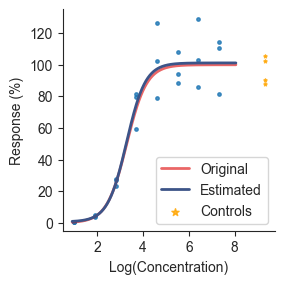


Plotting curve for compound 5
The score of this fit is: 0.9412162610231516

The original IC50 is: compound
5    54.361609
Name: e, dtype: float64

The estimated IC50 is: 68.09232459243029

The absolute log error is: compound
5    0.097806
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         5  10000.000000  1.00000   0.040065    0.051868
1         5   1250.000000  1.90309   0.898778    1.218833
2         5    156.250000  2.80618  17.027230   15.983685
3         5     19.531250  3.70927  82.280431   72.648913
4         5      2.441406  4.61236  99.057226   86.403495
5         5      0.305176  5.51545  99.957956  123.541557
6         5      0.038147  6.41854  99.998141  127.824929
7         5      0.004768  7.32163  99.999918   74.830536
0         5  10000.000000  1.00000   0.040065    0.029782
1         5   1250.000000  1.90309   0.898778    0.728354
2         5    156.250000  2.80618  17.027230   16.299032
3         5     19.531250  3.70927  82.

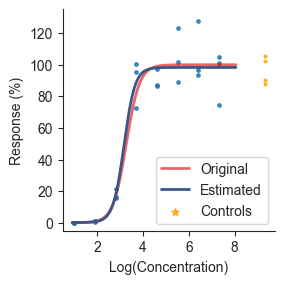


Plotting curve for compound 6
The score of this fit is: 0.9324592785786401

The original IC50 is: compound
6    53.715
Name: e, dtype: float64

The estimated IC50 is: 32.27778441212007

The absolute log error is: compound
6    0.221192
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         6  10000.000000  1.00000   6.828581    6.048572
1         6   1250.000000  1.90309  17.170332   13.699640
2         6    156.250000  2.80618  36.961181   31.798005
3         6     19.531250  3.70927  62.383036   65.631324
4         6      2.441406  4.61236  82.427139  104.428705
5         6      0.305176  5.51545  92.990818  112.005966
6         6      0.038147  6.41854  97.404266  112.044188
7         6      0.004768  7.32163  99.066607  105.048535
0         6  10000.000000  1.00000   6.828581    5.990622
1         6   1250.000000  1.90309  17.170332   21.253085
2         6    156.250000  2.80618  36.961181   38.272391
3         6     19.531250  3.70927  62.383

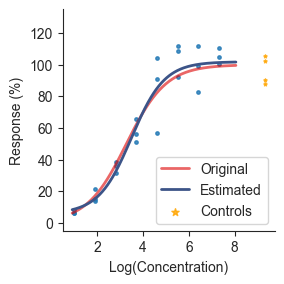


Plotting curve for compound 7
The score of this fit is: 0.9508432311343222

The original IC50 is: compound
7    50.31356
Name: e, dtype: float64

The estimated IC50 is: 60.87730524141119

The absolute log error is: compound
7    0.08277
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         7  10000.000000  1.00000   0.500617    0.410847
1         7   1250.000000  1.90309   3.869341    3.474336
2         7    156.250000  2.80618  24.357423   24.541989
3         7     19.531250  3.70927  72.036218   70.877667
4         7      2.441406  4.61236  95.372177  116.836150
5         7      0.305176  5.51545  99.397109   96.960194
6         7      0.038147  6.41854  99.924239   83.915001
7         7      0.004768  7.32163  99.990524   68.702058
0         7  10000.000000  1.00000   0.500617    0.377423
1         7   1250.000000  1.90309   3.869341    3.093901
2         7    156.250000  2.80618  24.357423   23.680941
3         7     19.531250  3.70927  72.03

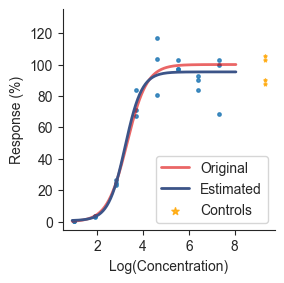


Plotting curve for compound 8
The score of this fit is: 0.9664477647974037

The original IC50 is: compound
8    52.190695
Name: e, dtype: float64

The estimated IC50 is: 41.09074347840937

The absolute log error is: compound
8    0.103849
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         8  10000.000000  1.00000   0.037690    0.041896
1         8   1250.000000  1.90309   0.845931    1.042239
2         8    156.250000  2.80618  16.180897   16.788643
3         8     19.531250  3.70927  81.371505   69.468841
4         8      2.441406  4.61236  98.998390   92.810155
5         8      0.305176  5.51545  99.955307   84.560545
6         8      0.038147  6.41854  99.998024  120.668775
7         8      0.004768  7.32163  99.999913   92.900260
0         8  10000.000000  1.00000   0.037690    0.033946
1         8   1250.000000  1.90309   0.845931    0.832653
2         8    156.250000  2.80618  16.180897   12.775745
3         8     19.531250  3.70927  81.

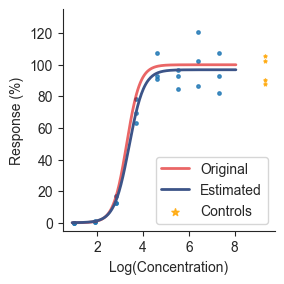


Plotting curve for compound 9
The score of this fit is: 0.9286125061836671

The original IC50 is: compound
9    51.733297
Name: e, dtype: float64

The estimated IC50 is: 56.59992680247076

The absolute log error is: compound
9    0.039046
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         9  10000.000000  1.00000   6.709966    5.514634
1         9   1250.000000  1.90309  16.904670   15.110044
2         9    156.250000  2.80618  36.524335   35.156898
3         9     19.531250  3.70927  61.940958   55.218501
4         9      2.441406  4.61236  82.153231  107.049860
5         9      0.305176  5.51545  92.867318   99.797953
6         9      0.038147  6.41854  97.356319   98.310629
7         9      0.004768  7.32163  99.049066  104.056578
0         9  10000.000000  1.00000   6.709966    5.225222
1         9   1250.000000  1.90309  16.904670   12.491653
2         9    156.250000  2.80618  36.524335   40.380798
3         9     19.531250  3.70927  61.

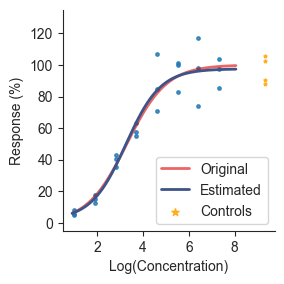


Plotting curve for compound 10
The score of this fit is: 0.9294431416914206

The original IC50 is: compound
10    51.982701
Name: e, dtype: float64

The estimated IC50 is: 60.374322376339684

The absolute log error is: compound
10    0.064993
Name: e, dtype: float64

   compound          dose  logDose   response     results
0        10  10000.000000  1.00000   0.517139    0.475192
1        10   1250.000000  1.90309   3.992580    4.278796
2        10    156.250000  2.80618  24.963755   25.062713
3        10     19.531250  3.70927  72.688895   83.283521
4        10      2.441406  4.61236  95.514109   77.670214
5        10      0.305176  5.51545  99.416355  133.379256
6        10      0.038147  6.41854  99.926670   92.441925
7        10      0.004768  7.32163  99.990828  111.239557
0        10  10000.000000  1.00000   0.517139    0.443557
1        10   1250.000000  1.90309   3.992580    4.765344
2        10    156.250000  2.80618  24.963755   18.108839
3        10     19.531250  3.70927 

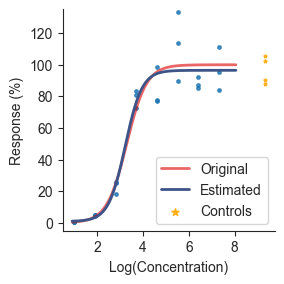


Plotting curve for compound 11
The score of this fit is: 0.9404944296574789

The original IC50 is: compound
11    50.703844
Name: e, dtype: float64

The estimated IC50 is: 54.01512078527124

The absolute log error is: compound
11    0.027474
Name: e, dtype: float64

   compound          dose  logDose   response     results
0        11  10000.000000  1.00000   0.036091    0.031179
1        11   1250.000000  1.90309   0.810332    0.623467
2        11    156.250000  2.80618  15.601490   17.652365
3        11     19.531250  3.70927  80.705380   78.222673
4        11      2.441406  4.61236  98.954476  108.182648
5        11      0.305176  5.51545  99.953328   99.087905
6        11      0.038147  6.41854  99.997936  110.974458
7        11      0.004768  7.32163  99.999909  116.848271
0        11  10000.000000  1.00000   0.036091    0.037354
1        11   1250.000000  1.90309   0.810332    0.773238
2        11    156.250000  2.80618  15.601490   13.908147
3        11     19.531250  3.70927  

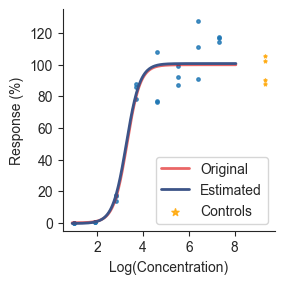

RESULT!!
0.057994366237106965
0.0886146947037813


compound
0     0.890373
1     0.947179
2     0.953919
3     0.939013
4     0.928278
5     0.941216
6     0.932459
7     0.950843
8     0.966448
9     0.928613
10    0.929443
11    0.940494
Name: r2_score, dtype: float64




Testing plates: PLAID
PLAID
plate_layout_20-12-8-3_01.npy

Plotting curve for compound 0
The score of this fit is: 0.9432170656958216

The original IC50 is: compound
0    50.892285
Name: e, dtype: float64

The estimated IC50 is: 30.80950361007704

The absolute log error is: compound
0    0.217967
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         0  10000.000000  1.00000   6.658848    7.947733
1         0   1250.000000  1.90309  16.789865   15.320059
2         0    156.250000  2.80618  36.334550   35.168343
3         0     19.531250  3.70927  61.747576   51.578158
4         0      2.441406  4.61236  82.032760   90.058902
5         0      0.305176  5.51545  92.812843  102.479

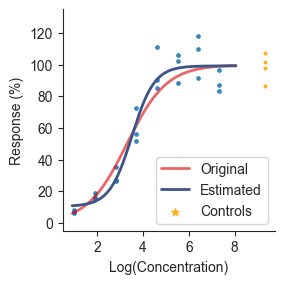


Plotting curve for compound 1
The score of this fit is: 0.9522273178610146

The original IC50 is: compound
1    53.439306
Name: e, dtype: float64

The estimated IC50 is: 55.48229693728518

The absolute log error is: compound
1    0.016294
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         1  10000.000000  1.00000   0.531552    0.400681
1         1   1250.000000  1.90309   4.099869    3.878734
2         1    156.250000  2.80618  25.484994   21.777931
3         1     19.531250  3.70927  73.234067   69.860858
4         1      2.441406  4.61236  95.631040   95.849145
5         1      0.305176  5.51545  99.432173  104.111162
6         1      0.038147  6.41854  99.928667   91.599683
7         1      0.004768  7.32163  99.991078  110.350754
0         1  10000.000000  1.00000   0.531552    0.444681
1         1   1250.000000  1.90309   4.099869    3.244658
2         1    156.250000  2.80618  25.484994   26.688780
3         1     19.531250  3.70927  73.

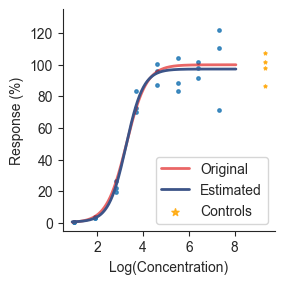


Plotting curve for compound 2
The score of this fit is: 0.9220961976592855

The original IC50 is: compound
2    54.133691
Name: e, dtype: float64

The estimated IC50 is: 49.93044513012249

The absolute log error is: compound
2    0.035102
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         2  10000.000000  1.00000   0.039813    0.042969
1         2   1250.000000  1.90309   0.893182    0.868547
2         2    156.250000  2.80618  16.938378   15.674750
3         2     19.531250  3.70927  82.188360   69.310228
4         2      2.441406  4.61236  99.051322  106.477555
5         2      0.305176  5.51545  99.957690   95.940381
6         2      0.038147  6.41854  99.998129   68.722119
7         2      0.004768  7.32163  99.999917   90.117369
0         2  10000.000000  1.00000   0.039813    0.044116
1         2   1250.000000  1.90309   0.893182    1.122496
2         2    156.250000  2.80618  16.938378   13.531953
3         2     19.531250  3.70927  82.

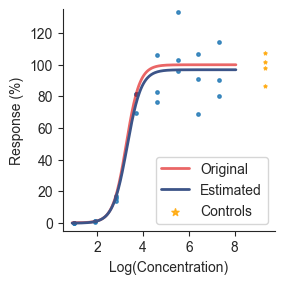


Plotting curve for compound 3
The score of this fit is: 0.9076896361063924

The original IC50 is: compound
3    54.482406
Name: e, dtype: float64

The estimated IC50 is: 102.43099410684496

The absolute log error is: compound
3    0.274175
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         3  10000.000000  1.00000   6.873846    5.485940
1         3   1250.000000  1.90309  17.271442   14.643149
2         3    156.250000  2.80618  37.126594   34.672928
3         3     19.531250  3.70927  62.549333   56.647439
4         3      2.441406  4.61236  82.529641  102.901790
5         3      0.305176  5.51545  93.036908   77.135225
6         3      0.038147  6.41854  97.422139  117.954753
7         3      0.004768  7.32163  99.073143  107.417532
0         3  10000.000000  1.00000   6.873846    5.376841
1         3   1250.000000  1.90309  17.271442   15.325011
2         3    156.250000  2.80618  37.126594   39.537633
3         3     19.531250  3.70927  62

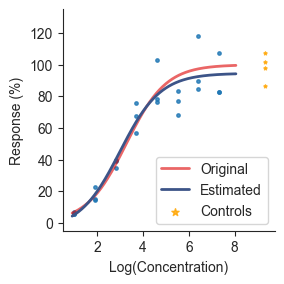


Plotting curve for compound 4
The score of this fit is: 0.9579277913899708

The original IC50 is: compound
4    51.922846
Name: e, dtype: float64

The estimated IC50 is: 39.99889452445084

The absolute log error is: compound
4    0.113311
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         4  10000.000000  1.00000   0.516546    0.598054
1         4   1250.000000  1.90309   3.988166    3.361044
2         4    156.250000  2.80618  24.942180   27.484370
3         4     19.531250  3.70927  72.666018   51.582471
4         4      2.441406  4.61236  95.509170  114.921058
5         4      0.305176  5.51545  99.415686   88.764043
6         4      0.038147  6.41854  99.926585  108.355357
7         4      0.004768  7.32163  99.990817  103.222254
0         4  10000.000000  1.00000   0.516546    0.424362
1         4   1250.000000  1.90309   3.988166    3.707749
2         4    156.250000  2.80618  24.942180   22.151210
3         4     19.531250  3.70927  72.

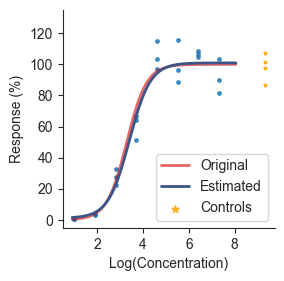


Plotting curve for compound 5
The score of this fit is: 0.9568044439612111

The original IC50 is: compound
5    54.361609
Name: e, dtype: float64

The estimated IC50 is: 50.08141893811104

The absolute log error is: compound
5    0.035616
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         5  10000.000000  1.00000   0.040065    0.036912
1         5   1250.000000  1.90309   0.898778    0.790812
2         5    156.250000  2.80618  17.027230   19.113125
3         5     19.531250  3.70927  82.280431   72.654246
4         5      2.441406  4.61236  99.057226   66.335687
5         5      0.305176  5.51545  99.957956   99.754174
6         5      0.038147  6.41854  99.998141  111.414025
7         5      0.004768  7.32163  99.999918   85.015624
0         5  10000.000000  1.00000   0.040065    0.036189
1         5   1250.000000  1.90309   0.898778    0.821912
2         5    156.250000  2.80618  17.027230   13.668919
3         5     19.531250  3.70927  82.

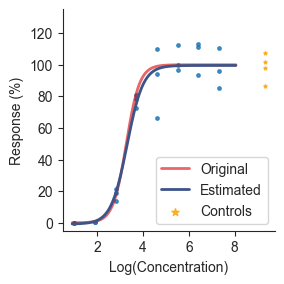


Plotting curve for compound 6
The score of this fit is: 0.8996787840925009

The original IC50 is: compound
6    53.715
Name: e, dtype: float64

The estimated IC50 is: 29.364504033148446

The absolute log error is: compound
6    0.262273
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         6  10000.000000  1.00000   6.828581    5.408998
1         6   1250.000000  1.90309  17.170332   19.225773
2         6    156.250000  2.80618  36.961181   30.284846
3         6     19.531250  3.70927  62.383036   52.648963
4         6      2.441406  4.61236  82.427139   83.642999
5         6      0.305176  5.51545  92.990818  119.191006
6         6      0.038147  6.41854  97.404266  113.296432
7         6      0.004768  7.32163  99.066607   71.843307
0         6  10000.000000  1.00000   6.828581    7.916496
1         6   1250.000000  1.90309  17.170332   15.738521
2         6    156.250000  2.80618  36.961181   39.509409
3         6     19.531250  3.70927  62.38

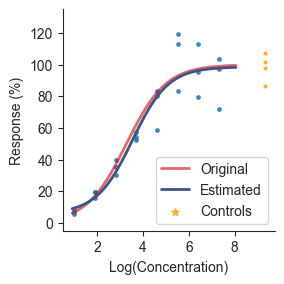


Plotting curve for compound 7
The score of this fit is: 0.9673420926853343

The original IC50 is: compound
7    50.31356
Name: e, dtype: float64

The estimated IC50 is: 48.626415795887915

The absolute log error is: compound
7    0.014813
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         7  10000.000000  1.00000   0.500617    0.424749
1         7   1250.000000  1.90309   3.869341    4.733500
2         7    156.250000  2.80618  24.357423   24.334352
3         7     19.531250  3.70927  72.036218   64.760037
4         7      2.441406  4.61236  95.372177  102.701229
5         7      0.305176  5.51545  99.397109   81.232541
6         7      0.038147  6.41854  99.924239   96.069584
7         7      0.004768  7.32163  99.990524   96.426007
0         7  10000.000000  1.00000   0.500617    0.453436
1         7   1250.000000  1.90309   3.869341    3.787965
2         7    156.250000  2.80618  24.357423   19.818780
3         7     19.531250  3.70927  72.

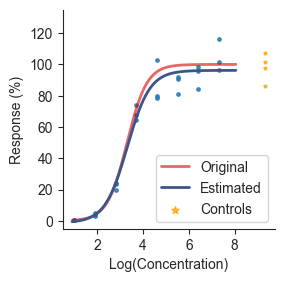


Plotting curve for compound 8
The score of this fit is: 0.940867084548105

The original IC50 is: compound
8    52.190695
Name: e, dtype: float64

The estimated IC50 is: 73.54220906673726

The absolute log error is: compound
8    0.148944
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         8  10000.000000  1.00000   0.037690    0.038432
1         8   1250.000000  1.90309   0.845931    0.908810
2         8    156.250000  2.80618  16.180897   16.460414
3         8     19.531250  3.70927  81.371505   70.850387
4         8      2.441406  4.61236  98.998390   90.827374
5         8      0.305176  5.51545  99.955307   85.517348
6         8      0.038147  6.41854  99.998024  117.017703
7         8      0.004768  7.32163  99.999913   77.911241
0         8  10000.000000  1.00000   0.037690    0.033954
1         8   1250.000000  1.90309   0.845931    0.735935
2         8    156.250000  2.80618  16.180897   19.049328
3         8     19.531250  3.70927  81.3

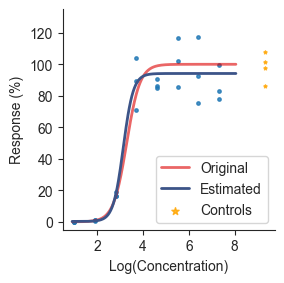


Plotting curve for compound 9
The score of this fit is: 0.9055579615060166

The original IC50 is: compound
9    51.733297
Name: e, dtype: float64

The estimated IC50 is: 46.56801371114774

The absolute log error is: compound
9    0.045682
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         9  10000.000000  1.00000   6.709966    7.409441
1         9   1250.000000  1.90309  16.904670   14.128756
2         9    156.250000  2.80618  36.524335   32.862513
3         9     19.531250  3.70927  61.940958   64.938406
4         9      2.441406  4.61236  82.153231   95.804094
5         9      0.305176  5.51545  92.867318   80.876931
6         9      0.038147  6.41854  97.356319   76.767490
7         9      0.004768  7.32163  99.049066  104.049543
0         9  10000.000000  1.00000   6.709966    7.148585
1         9   1250.000000  1.90309  16.904670   13.812460
2         9    156.250000  2.80618  36.524335   32.966509
3         9     19.531250  3.70927  61.

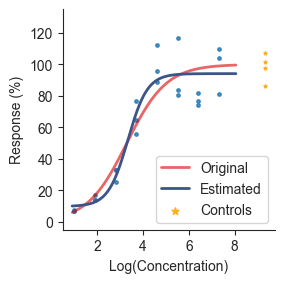


Plotting curve for compound 10
The score of this fit is: 0.9561866229339515

The original IC50 is: compound
10    51.982701
Name: e, dtype: float64

The estimated IC50 is: 63.31817993872739

The absolute log error is: compound
10    0.08567
Name: e, dtype: float64

   compound          dose  logDose   response     results
0        10  10000.000000  1.00000   0.517139    0.461722
1        10   1250.000000  1.90309   3.992580    4.510018
2        10    156.250000  2.80618  24.963755   25.575582
3        10     19.531250  3.70927  72.688895   66.564125
4        10      2.441406  4.61236  95.514109   88.255501
5        10      0.305176  5.51545  99.416355   77.811086
6        10      0.038147  6.41854  99.926670   93.021490
7        10      0.004768  7.32163  99.990828   86.607514
0        10  10000.000000  1.00000   0.517139    0.531691
1        10   1250.000000  1.90309   3.992580    4.246129
2        10    156.250000  2.80618  24.963755   29.608484
3        10     19.531250  3.70927  7

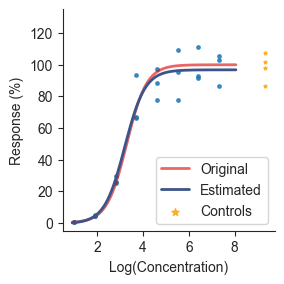


Plotting curve for compound 11
The score of this fit is: 0.9589506139358202

The original IC50 is: compound
11    50.703844
Name: e, dtype: float64

The estimated IC50 is: 50.361304399768926

The absolute log error is: compound
11    0.002944
Name: e, dtype: float64

   compound          dose  logDose   response     results
0        11  10000.000000  1.00000   0.036091    0.031890
1        11   1250.000000  1.90309   0.810332    0.955201
2        11    156.250000  2.80618  15.601490   15.235302
3        11     19.531250  3.70927  80.705380   69.010993
4        11      2.441406  4.61236  98.954476  114.319033
5        11      0.305176  5.51545  99.953328   87.720161
6        11      0.038147  6.41854  99.997936  119.939073
7        11      0.004768  7.32163  99.999909   97.026902
0        11  10000.000000  1.00000   0.036091    0.044752
1        11   1250.000000  1.90309   0.810332    0.818559
2        11    156.250000  2.80618  15.601490   13.239445
3        11     19.531250  3.70927 

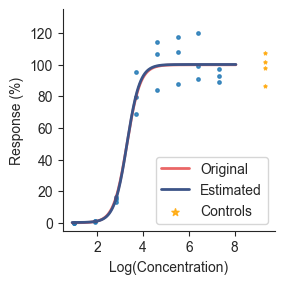

RESULT!!
0.0700309968078694
0.10439913134122546


compound
0     0.943217
1     0.952227
2     0.922096
3     0.907690
4     0.957928
5     0.956804
6     0.899679
7     0.967342
8     0.940867
9     0.905558
10    0.956187
11    0.958951
Name: r2_score, dtype: float64




Testing plates: Random
Random
plate_layout_rand_02.npy

Plotting curve for compound 0
The score of this fit is: 0.9285541466249807

The original IC50 is: compound
0    50.892285
Name: e, dtype: float64

The estimated IC50 is: 27.853074428931333

The absolute log error is: compound
0    0.261779
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         0  10000.000000  1.00000   6.658848    7.324981
1         0   1250.000000  1.90309  16.789865   14.860348
2         0    156.250000  2.80618  36.334550   32.065326
3         0     19.531250  3.70927  61.747576   56.992639
4         0      2.441406  4.61236  82.032760  100.200989
5         0      0.305176  5.51545  92.812843   84.697711

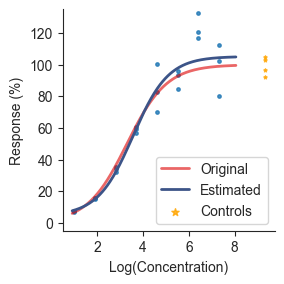


Plotting curve for compound 1
The score of this fit is: 0.9115491163151931

The original IC50 is: compound
1    53.439306
Name: e, dtype: float64

The estimated IC50 is: 61.92371506082417

The absolute log error is: compound
1    0.063996
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         1  10000.000000  1.00000   0.531552    0.478472
1         1   1250.000000  1.90309   4.099869    4.663082
2         1    156.250000  2.80618  25.484994   30.199838
3         1     19.531250  3.70927  73.234067  101.223944
4         1      2.441406  4.61236  95.631040   87.130716
5         1      0.305176  5.51545  99.432173   74.959444
6         1      0.038147  6.41854  99.928667  104.661704
7         1      0.004768  7.32163  99.991078  107.037770
0         1  10000.000000  1.00000   0.531552    0.743007
1         1   1250.000000  1.90309   4.099869    3.352150
2         1    156.250000  2.80618  25.484994   24.788283
3         1     19.531250  3.70927  73.

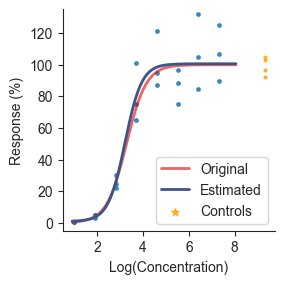


Plotting curve for compound 2
The score of this fit is: 0.9367212546152086

The original IC50 is: compound
2    54.133691
Name: e, dtype: float64

The estimated IC50 is: 81.85934415189854

The absolute log error is: compound
2    0.179601
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         2  10000.000000  1.00000   0.039813    0.033718
1         2   1250.000000  1.90309   0.893182    1.119237
2         2    156.250000  2.80618  16.938378   14.089652
3         2     19.531250  3.70927  82.188360  100.304448
4         2      2.441406  4.61236  99.051322   84.137406
5         2      0.305176  5.51545  99.957690   87.050207
6         2      0.038147  6.41854  99.998129   71.708840
7         2      0.004768  7.32163  99.999917   78.417155
0         2  10000.000000  1.00000   0.039813    0.040195
1         2   1250.000000  1.90309   0.893182    0.874101
2         2    156.250000  2.80618  16.938378   14.117373
3         2     19.531250  3.70927  82.

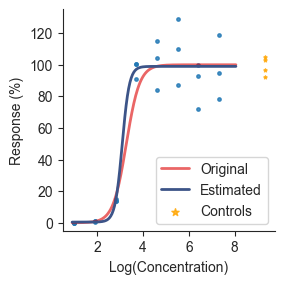


Plotting curve for compound 3
The score of this fit is: 0.9252416977401927

The original IC50 is: compound
3    54.482406
Name: e, dtype: float64

The estimated IC50 is: 54.5226620293119

The absolute log error is: compound
3    0.000321
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         3  10000.000000  1.00000   6.873846    7.182979
1         3   1250.000000  1.90309  17.271442   17.680884
2         3    156.250000  2.80618  37.126594   35.261492
3         3     19.531250  3.70927  62.549333   74.344977
4         3      2.441406  4.61236  82.529641  108.137301
5         3      0.305176  5.51545  93.036908  121.823854
6         3      0.038147  6.41854  97.422139  112.383247
7         3      0.004768  7.32163  99.073143  100.661105
0         3  10000.000000  1.00000   6.873846    7.787701
1         3   1250.000000  1.90309  17.271442   14.758355
2         3    156.250000  2.80618  37.126594   38.754425
3         3     19.531250  3.70927  62.5

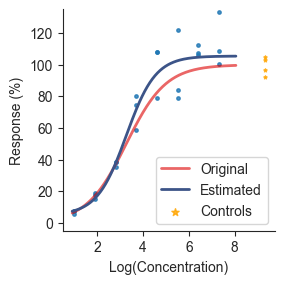


Plotting curve for compound 4
The score of this fit is: 0.9451740462920076

The original IC50 is: compound
4    51.922846
Name: e, dtype: float64

The estimated IC50 is: 66.1630982249613

The absolute log error is: compound
4    0.105257
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         4  10000.000000  1.00000   0.516546    0.585752
1         4   1250.000000  1.90309   3.988166    3.048105
2         4    156.250000  2.80618  24.942180   27.551705
3         4     19.531250  3.70927  72.666018   95.831633
4         4      2.441406  4.61236  95.509170  111.760865
5         4      0.305176  5.51545  99.415686  105.856537
6         4      0.038147  6.41854  99.926585   94.095666
7         4      0.004768  7.32163  99.990817   89.754851
0         4  10000.000000  1.00000   0.516546    0.460354
1         4   1250.000000  1.90309   3.988166    3.526374
2         4    156.250000  2.80618  24.942180   24.556965
3         4     19.531250  3.70927  72.6

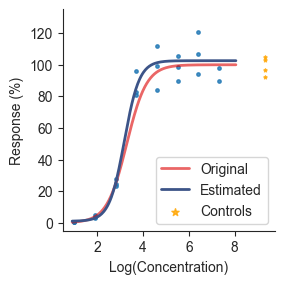


Plotting curve for compound 5
The score of this fit is: 0.9351284687516663

The original IC50 is: compound
5    54.361609
Name: e, dtype: float64

The estimated IC50 is: 74.71476375747115

The absolute log error is: compound
5    0.138114
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         5  10000.000000  1.00000   0.040065    0.040413
1         5   1250.000000  1.90309   0.898778    0.864512
2         5    156.250000  2.80618  17.027230   23.347299
3         5     19.531250  3.70927  82.280431  104.544809
4         5      2.441406  4.61236  99.057226  108.366370
5         5      0.305176  5.51545  99.957956  134.037888
6         5      0.038147  6.41854  99.998141   83.053026
7         5      0.004768  7.32163  99.999918  108.806922
0         5  10000.000000  1.00000   0.040065    0.047099
1         5   1250.000000  1.90309   0.898778    0.759485
2         5    156.250000  2.80618  17.027230   20.796811
3         5     19.531250  3.70927  82.

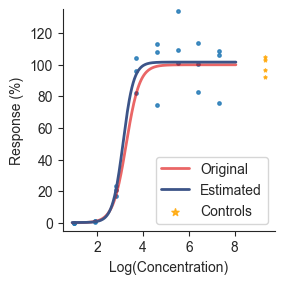


Plotting curve for compound 6
The score of this fit is: 0.8966276529732228

The original IC50 is: compound
6    53.715
Name: e, dtype: float64

The estimated IC50 is: 58.42655816435496

The absolute log error is: compound
6    0.036515
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         6  10000.000000  1.00000   6.828581    6.293095
1         6   1250.000000  1.90309  17.170332   17.030637
2         6    156.250000  2.80618  36.961181   36.119821
3         6     19.531250  3.70927  62.383036   58.995778
4         6      2.441406  4.61236  82.427139   91.237680
5         6      0.305176  5.51545  92.990818   66.419021
6         6      0.038147  6.41854  97.404266  134.562471
7         6      0.004768  7.32163  99.066607  105.865427
0         6  10000.000000  1.00000   6.828581    9.951873
1         6   1250.000000  1.90309  17.170332   22.498539
2         6    156.250000  2.80618  36.961181   44.718108
3         6     19.531250  3.70927  62.383

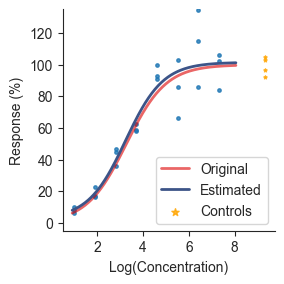


Plotting curve for compound 7
The score of this fit is: 0.9503968492251433

The original IC50 is: compound
7    50.31356
Name: e, dtype: float64

The estimated IC50 is: 63.48563418663234

The absolute log error is: compound
7    0.10099
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         7  10000.000000  1.00000   0.500617    0.526928
1         7   1250.000000  1.90309   3.869341    4.146709
2         7    156.250000  2.80618  24.357423   22.195473
3         7     19.531250  3.70927  72.036218   77.361624
4         7      2.441406  4.61236  95.372177  111.181481
5         7      0.305176  5.51545  99.397109  127.087133
6         7      0.038147  6.41854  99.924239  100.803537
7         7      0.004768  7.32163  99.990524  107.103435
0         7  10000.000000  1.00000   0.500617    0.631566
1         7   1250.000000  1.90309   3.869341    4.219084
2         7    156.250000  2.80618  24.357423   20.326478
3         7     19.531250  3.70927  72.03

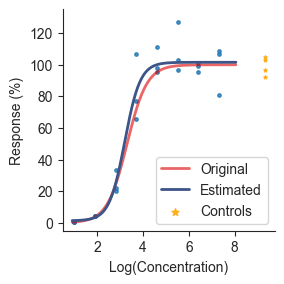


Plotting curve for compound 8
The score of this fit is: 0.9715541319399214

The original IC50 is: compound
8    52.190695
Name: e, dtype: float64

The estimated IC50 is: 43.66719893781395

The absolute log error is: compound
8    0.077438
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         8  10000.000000  1.00000   0.037690    0.035559
1         8   1250.000000  1.90309   0.845931    0.751142
2         8    156.250000  2.80618  16.180897   13.591041
3         8     19.531250  3.70927  81.371505   86.713773
4         8      2.441406  4.61236  98.998390  112.799451
5         8      0.305176  5.51545  99.955307  115.615027
6         8      0.038147  6.41854  99.998024   96.752200
7         8      0.004768  7.32163  99.999913  102.653630
0         8  10000.000000  1.00000   0.037690    0.037948
1         8   1250.000000  1.90309   0.845931    0.780196
2         8    156.250000  2.80618  16.180897   16.928414
3         8     19.531250  3.70927  81.

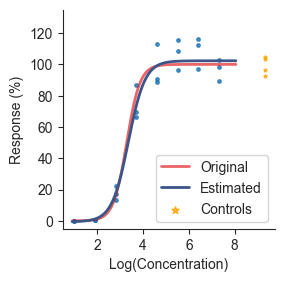


Plotting curve for compound 9
The score of this fit is: 0.896929158064073

The original IC50 is: compound
9    51.733297
Name: e, dtype: float64

The estimated IC50 is: 17.1953167231925

The absolute log error is: compound
9    0.47836
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         9  10000.000000  1.00000   6.709966    6.942907
1         9   1250.000000  1.90309  16.904670   21.856669
2         9    156.250000  2.80618  36.524335   31.486133
3         9     19.531250  3.70927  61.940958   53.104370
4         9      2.441406  4.61236  82.153231   68.716491
5         9      0.305176  5.51545  92.867318   80.884719
6         9      0.038147  6.41854  97.356319  131.287425
7         9      0.004768  7.32163  99.049066   93.500611
0         9  10000.000000  1.00000   6.709966    8.720864
1         9   1250.000000  1.90309  16.904670   20.184879
2         9    156.250000  2.80618  36.524335   33.308843
3         9     19.531250  3.70927  61.940

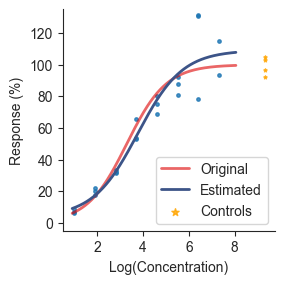


Plotting curve for compound 10
The score of this fit is: 0.9617737897935651

The original IC50 is: compound
10    51.982701
Name: e, dtype: float64

The estimated IC50 is: 70.25623197884242

The absolute log error is: compound
10    0.130826
Name: e, dtype: float64

   compound          dose  logDose   response     results
0        10  10000.000000  1.00000   0.517139    0.466736
1        10   1250.000000  1.90309   3.992580    3.778540
2        10    156.250000  2.80618  24.963755   22.944059
3        10     19.531250  3.70927  72.688895   64.824015
4        10      2.441406  4.61236  95.514109   87.643642
5        10      0.305176  5.51545  99.416355   78.176776
6        10      0.038147  6.41854  99.926670   82.738021
7        10      0.004768  7.32163  99.990828   85.800605
0        10  10000.000000  1.00000   0.517139    0.541054
1        10   1250.000000  1.90309   3.992580    3.986115
2        10    156.250000  2.80618  24.963755   27.880553
3        10     19.531250  3.70927  

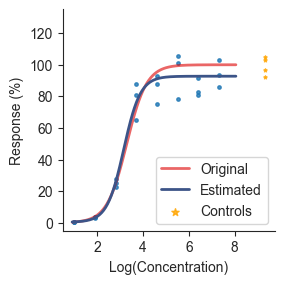


Plotting curve for compound 11
The score of this fit is: 0.9223628296076978

The original IC50 is: compound
11    50.703844
Name: e, dtype: float64

The estimated IC50 is: 46.41527787793419

The absolute log error is: compound
11    0.03838
Name: e, dtype: float64

   compound          dose  logDose   response     results
0        11  10000.000000  1.00000   0.036091    0.053068
1        11   1250.000000  1.90309   0.810332    0.974043
2        11    156.250000  2.80618  15.601490   14.547063
3        11     19.531250  3.70927  80.705380   87.659154
4        11      2.441406  4.61236  98.954476   70.420901
5        11      0.305176  5.51545  99.953328   98.465082
6        11      0.038147  6.41854  99.997936   97.394753
7        11      0.004768  7.32163  99.999909  104.973420
0        11  10000.000000  1.00000   0.036091    0.051020
1        11   1250.000000  1.90309   0.810332    0.993450
2        11    156.250000  2.80618  15.601490   13.267745
3        11     19.531250  3.70927  8

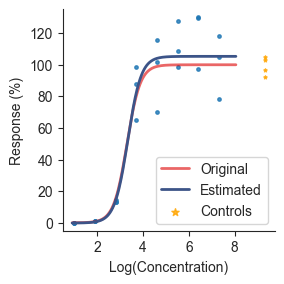

RESULT!!
0.11566102180941235
0.13429805579844517


compound
0     0.928554
1     0.911549
2     0.936721
3     0.925242
4     0.945174
5     0.935128
6     0.896628
7     0.950397
8     0.971554
9     0.896929
10    0.961774
11    0.922363
Name: r2_score, dtype: float64






In [7]:
#for current_e in range(1,100,5):
for current_e in range(50,51,5):
    print("Testing e:",current_e)
    
    # Create new curves/compounds
    params = []
    for i in range(compounds):
        params.append({'compound':i, 'b':slopes[i%3], 'c':0, 'd':100, 'e':(current_e+5*np.random.random()),'startDose':10000, 'nDose':concentrations, 'dilution':dilution})
    
    df_params = pd.DataFrame.from_dict(params)
    df_params.set_index('compound',inplace=True)

    df_params['abs IC50'] = dr.IC50(df_params['b'],df_params['c'],df_params['d'],df_params['e'])
    
    print(df_params)

    compounds_array = df_params.index.to_numpy()

    # The same compounds/concentrations will be used in every plate
    plate_content = dr.generate_plate_content(dose_response_params=params, replicates=replicates)
    
    for plate_type in plate_types_location:
        print("Testing plates:",plate_type['type'])
        layout_dir = plate_type['dir']
        layouts = os.listdir(layout_dir)

        print(plate_type['type'])

        if plate_type['type'] == 'Random':
            layouts = ["plate_layout_rand_02.npy"]
        elif plate_type['type'] == 'PLAID':
            layouts = ["plate_layout_20-8-12-3_01.npy","plate_layout_20-24-12-1_09.npy","plate_layout_48-6-1_01.npy","plate_layout_24-6-2_01.npy","plate_layout_20-36-8-1_02.npy","plate_layout_20-18-8-2_02.npy","plate_layout_20-12-8-3_01.npy"]
        else:
            layouts = ["plate_layout_40-8-12-3_01.npy","plate_layout_40-24-12-1_09.npy","plate_layout_40_48-6-1_01.npy","plate_layout_40_24-6-2_01.npy","plate_layout_40-36-8-1_02.npy","plate_layout_40-18-8-2_02.npy","plate_layout_40-12-8-3_01.npy"]
        
        for layout_file in layouts:
            match = re.search(plate_type['regex'],layout_file)

            if match == None:
                continue

            
            print(layout_file)
            
            layout_file_array = np.full(len(compounds_array),layout_file)
            
            e_array = np.full(len(compounds_array),current_e)

            for et in error_types:
                error_type_array = np.full(len(compounds_array),et['type'])
                error_array = np.full(len(compounds_array),et['error'])    
                for lost_rows in range(1,2): #max 8
                    limits = [#{'from':0, 'to':lost_rows},
                              {'from':16-lost_rows,'to':16}]
                    for limit in limits:
                        r_lost_array = np.full(len(compounds_array),lost_rows)

                        if plate_type['type'] == 'COMPD':
                            if layout_file == "plate_layout_40-8-12-3_01.npy":
                                compounds,concentrations,replicates = 8,12,3
                            elif layout_file == "plate_layout_40-24-12-1_09.npy":
                                compounds,concentrations,replicates = 24,12,1
                            elif layout_file == "plate_layout_40_48-6-1_01.npy":
                                compounds,concentrations,replicates = 48, 6,1
                            elif layout_file == "plate_layout_40_24-6-2_01.npy":
                                compounds,concentrations,replicates = 24, 6,2
                            elif layout_file == "plate_layout_40-36-8-1_02.npy":
                                compounds,concentrations,replicates = 36, 8,1
                            elif layout_file == "plate_layout_40-18-8-2_02.npy":
                                compounds,concentrations,replicates = 18, 8,2
                            elif layout_file == "plate_layout_40-12-8-3_01.npy":
                                compounds,concentrations,replicates = 12, 8,3
                        else:
                            compounds=None
                            concentrations=None
                            replicates=None
                            
                        fitTable_new = dr.plate_curves_after_error(layout_dir,layout_file,plate_content,expected_noise,et['error_function'],et['error'],plate_type['error_correction'],my_min_dist,lose_from_row=limit['from'],lose_to_row=limit['to'], df_params=df_params,
                                                                   plate_type=plate_type,compounds=compounds,concentrations=concentrations,replicates=replicates)

                        #print('fitTable_new')
                        #print(fitTable_new)
                        #print('end Table')
                        
                        
                        obtained_absolute_ic50 = dr.IC50(fitTable_new['b'],fitTable_new['c'],fitTable_new['d'],fitTable_new['e'])
                        #plate_mse = np.absolute(np.subtract(fitTable_new['abs IC50'], obtained_absolute_ic50)).mean()

                        #print(obtained_absolute_ic50)
                        
                        res_array = np.concatenate(fitTable_new['residuals'].to_numpy())
                        true_res_array = np.concatenate(fitTable_new['true_residuals'].to_numpy())
                        res_size = len(res_array)
                        
                        plate_residuals = np.vstack([np.full(res_size,layout_file), np.full(res_size,et['type']), np.full(res_size,et['error']), np.full(res_size,current_e), np.full(res_size,lost_rows), res_array, true_res_array])
                        
                        #print(plate_residuals)
                        
                        #print(len(np.concatenate(fitTable_new['residuals'].to_numpy())))
                        
                        #print(plate_residuals.T)
                        residuals = np.vstack([residuals,plate_residuals.T])
                        np.savetxt(residuals_f, plate_residuals.T, delimiter=",",fmt='%s')
                        
                        plate_rel_ic50 = np.absolute(np.subtract(np.log10(df_params['e']), np.log10(fitTable_new['e'])))
                        plate_abs_ic50 = np.absolute(np.subtract(np.log10(df_params['abs IC50']), np.log10(obtained_absolute_ic50)))

                        print("RESULT!!")
                        print(plate_abs_ic50.mean())
                        print(plate_rel_ic50.mean())
                        print("\n")
                        print(fitTable_new['r2_score'])
                        print("\n")
                        
                        rel_results = np.vstack([layout_file_array, compounds_array, plate_rel_ic50.to_numpy(), error_type_array, error_array, e_array, r_lost_array])
                        abs_results = np.vstack([layout_file_array, compounds_array, plate_abs_ic50.to_numpy(), error_type_array, error_array, e_array, r_lost_array])

                        #relative_ic50_data = np.vstack([relative_ic50_data,rel_results.T])
                        #absolute_ic50_data = np.vstack([absolute_ic50_data,abs_results.T])

                        np.savetxt(absolute_ic50_data_f, abs_results.T, delimiter=",",fmt='%s')
                        np.savetxt(relative_ic50_data_f, rel_results.T, delimiter=",",fmt='%s')
                        
                        print("\n")
                        #for _, row in fitTable_new.iterrows():
                         #   temp = dr.IC50(row.b,row.c,row.d,row.e)
                          #  if temp > 100:
                           #     print(row)

                        #print("MSE "+layout_file,":",plate_abs_ic50.mean())
# np.savetxt("my_array.csv", my_array, fmt="%4d", delimiter=",", newline="\n")

In [8]:
absolute_ic50_data_f.close()
relative_ic50_data_f.close()
residuals_f.close()

done_f=open('done-'+str(compounds)+'-'+str(concentrations)+'-dil'+str(dilution)+'-'+str(replicates)+'-'+str(error_nl)+'-'+today+'.csv','a')
done_f.close()

assert False

AssertionError: 

In [ ]:
np.power(10,np.log10([2,4,5]))

In [ ]:
def ll4(x,b,c,d,e): return c + (d-c)/(1+np.exp(b*(np.log(x)-np.log(e))))
def ll42(x,b,c,d,e): return  ( (d-c)/(1+ (x/e)**b  ) ) + c 

def ic50(b,c,d,e): return np.exp(np.log((((d-c)/(50-c)) -1)*(e**b))/b)

dil = 4
start = 10000
#print(ll4(0,0.755487,-33246.46969,99.415264,4.06E+05))
print(dr.ll4(start,2,0,100,40))
print(dr.ll4(start/dil,2,0,100,40))
print(dr.ll4(start/dil**2,2,0,100,40))
print(dr.ll4(start/dil**3,2,0,100,40))
print(dr.ll4(start/dil**4,2,0,100,40))
print(dr.ll4(start/dil**5,2,0,100,40))
print(dr.ll4(start/dil**6,2,0,100,40))
print(dr.ll4(start/dil**7,2,0,100,40))
print(dr.ll4(start/dil**8,2,0,100,40))
print(dr.ll4(start/dil**9,2,0,100,40))
print(dr.ll4(start/dil**10,2,0,100,40))
print(dr.ll4(start/dil**11,2,0,100,40))
print("\n")


print(dr.ll4(start,0.5,0,100,40))
print(dr.ll4(start/dil,0.5,0,100,40))
print(dr.ll4(start/dil**2,0.5,0,100,40))
print(dr.ll4(start/dil**3,0.5,0,100,40))
print(dr.ll4(start/dil**4,0.5,0,100,40))
print(dr.ll4(start/dil**5,0.5,0,100,40))
print(dr.ll4(start/dil**6,0.5,0,100,40))
print(dr.ll4(start/(dil**7),0.5,0,100,40))
print(dr.ll4(start/dil**8,0.5,0,100,40))
print(dr.ll4(start/dil**9,0.5,0,100,40))
print(dr.ll4(start/dil**10,0.5,0,100,40))
print(dr.ll4(start/(dil**11),0.5,0,100,40))
print("\n")


print(ll42(200,2,0,100,10))

print(ll4(10**-6,2,0,100,40))
print(dr.ll4(0.002603082049,2,0,100,40))
print(ll42(0.0000009486450616,2,0,100,40))

#print(ic50(2,0,100,60))


print("check")
small_start = 0.001
print(dr.ll4(small_start,0.5,0,100,40))
print(dr.ll4(small_start*dil,0.5,0,100,40))
print(dr.ll4(small_start*dil**2,0.5,0,100,40))
print(dr.ll4(small_start*dil**3,0.5,0,100,40))
print(dr.ll4(small_start*dil**4,0.5,0,100,40))
print(dr.ll4(small_start*dil**5,0.5,0,100,40))
print(dr.ll4(small_start*dil**6,0.5,0,100,40))
print(dr.ll4(small_start*(dil**7),0.5,0,100,40))
print(dr.ll4(small_start*dil**8,0.5,0,100,40))
print(dr.ll4(small_start*dil**9,0.5,0,100,40))
print(dr.ll4(small_start*dil**10,0.5,0,100,40))
print(dr.ll4(small_start*(dil**11),0.5,0,100,40))

In [ ]:
print(np.random.random())

## Evaluating the absolute IC50

We first look at the mean IC50 obtained for all the compounds using a PLAID layout versus a completly random layout. 

In [ ]:
print(2**3)
## Loading data for a high error=0.125
# 1 replicate
#absolute_ic50_data = np.loadtxt('absolute_ic50_data-48-6-1-20210630.csv', delimiter=',', dtype='str')

# 2 replicate
#absolute_ic50_data = np.loadtxt('absolute_ic50_data-20210621.csv', delimiter=',', dtype='str')

# 3 replicates
#absolute_ic50_data = np.loadtxt('absolute_ic50_data-16-6-3complete-20210716.csv', delimiter=',', dtype='str')


## Loading data for a low error=0.025
# 1 replicate
#absolute_ic50_data = np.loadtxt('absolute_ic50_data-16-6-3-0.025-20210921.csv', delimiter=',', dtype='str')

## Loading data for a high error=0.125 and 4 doses
# 2 replicates
#absolute_ic50_data = np.loadtxt('absolute_ic50_data-36-4-2-8-20211212.csv', delimiter=',', dtype='str')

In [ ]:
results_df = pd.DataFrame(absolute_ic50_data, columns=["layout", "compound_id", "MSE", "error type", "Error", "E", "rows lost"])
results_df.MSE = pd.to_numeric(results_df.MSE, errors='coerce')
#results_df.MSE = pd.to_numeric(results_df.MSE, errors='coerce')

results_df = results_df.sort_values("MSE")

results_df = results_df[np.logical_not(np.isnan(results_df['MSE']))]

#results_df = results_df.loc[(results_df['error type'] != "bowl") & (results_df['error type'] != "left") & (results_df['error type'] != "top")]

print(results_df)

results_df.loc[(results_df['layout'] >= "plate_layout_rand"), 'layout'] = "RANDOM"
results_df.loc[(results_df['layout'] >= "plate_layout_border") & (results_df['layout'] != "RANDOM"), 'layout'] = "BORDER"
results_df.loc[(results_df['layout'] >= "plate_layout") & (results_df['layout'] != "RANDOM") & (results_df['layout'] != "BORDER"), 'layout'] = "TEST"


#print(results_df[results_df['layout']=='PLAID'].describe())

print(results_df[results_df['layout']=='RANDOM'].describe())

print(results_df[results_df['layout']=='BORDER'].describe())

fig, ax = plt.subplots(figsize=(4, 4))

ax.set(ylim=(0,1))


ax = sns.barplot(x="layout", y="MSE", data=results_df[results_df['MSE']!=np.inf], order=["TEST", "RANDOM", "BORDER"])

#ax = sns.barplot(x="layout", y="MSE", data=results_df[results_df['MSE']!=np.inf], order=["PLAID", "RANDOM"])

ax.set(xlabel='', ylabel='')

plt.show()


In [ ]:
fig.savefig("dose-response-absic50-48-4-2-sq-essense.png",bbox_inches='tight')

In [ ]:
## Plot Absolute IC50
results_df = pd.DataFrame(absolute_ic50_data, columns=["layout", "method", "MSE", "error type", "Error", "E", "rows lost"])
results_df.MSE = pd.to_numeric(results_df.MSE, errors='coerce')

results_df["rows lost"] = pd.to_numeric(results_df["rows lost"], errors='coerce')
results_df["E"] = pd.to_numeric(results_df["E"], errors='coerce')

results_df = results_df.sort_values("MSE")

results_df = results_df[np.logical_not(np.isnan(results_df['MSE']))]
print(results_df)

results_df.loc[(results_df['layout'] >= "plate_layout_rand"), 'layout'] = "RANDOM"
results_df.loc[(results_df['layout'] >= "plate_layout_border") & (results_df['layout'] != "RANDOM"), 'layout'] = "BORDER"
results_df.loc[(results_df['layout'] >= "plate_layout") & (results_df['layout'] != "RANDOM") & (results_df['layout'] != "BORDER"), 'layout'] = "PLAID"

temp_none = results_df[(results_df['MSE']!=np.inf) & (results_df['rows lost']<2) ]

#print(temp_none[temp_none['layout']=='PLAID'].describe())

#print(temp_none[temp_none['layout']=='RANDOM'].describe())

#print(temp_none[temp_none['layout']=='BORDER'].describe())


#temp_half = results_df[(results_df['MSE']!=np.inf) & (results_df['rows lost']<=1) & (results_df['E']>70) & (results_df['E']<80) ]
temp_half = results_df[(results_df['rows lost']<=1) & (results_df['MSE']!=np.inf) ]
#ax = sns.barplot(x="layout", y="MSE", data=temp_half, order=["PLAID", "RANDOM"])
#plt.show()

print(temp_half[temp_half['layout']=='PLAID'].describe())

print(temp_half[temp_half['layout']=='RANDOM'].describe())

#print(temp_half[temp_half['layout']=='BORDER'].describe())


fig, ax = plt.subplots(figsize=(6, 15))

ax.set(ylim=(0,0.6))

ax = sns.barplot(x="layout", y="MSE", data=temp_half, order=["PLAID", "RANDOM","BORDER"])
#plt.show()

In [ ]:
fig.savefig("dose-response-absic50-16-6-3.png",bbox_inches='tight')

In [ ]:
import ptitprince as pt

#temp_half.loc[(temp_half['layout']=='PLAID') & (temp_half["MSE"]>0.688),"MSE"] = 0.1

fig, ax = plt.subplots(figsize=(15, 10))

#ax = sns.barplot(x="layout", y="MSE", data=temp_half, order=["PLAID", "RANDOM"])

#sns.barplot(x = "group", y = "score", data = df, capsize= .1)
pal = sns.color_palette(n_colors=1)

#ax=pt.half_violinplot( x = "MSE", y = "layout", data = temp_half, palette = pal, bw = .2, cut = 0.,
 #                     scale = "area", width = .6, inner = None, orient = ort, order=["PLAID", "RANDOM"])

dx = "MSE"; dy = "layout"; ort = "h"; pal = "Set2"; sigma = 0.01
#f, ax = plt.subplots(figsize=(7, 5))

pt.RainCloud(x = "layout", y = "MSE", data = temp_none, palette = pal, bw = sigma,
                 width_viol = 1.3, ax = ax, orient = ort, order=["PLAID", "RANDOM","BORDER"], jitter = 0.15)

#ax = sns.violinplot(x="MSE", y="layout", data=temp_half, order=["PLAID", "RANDOM"])
#ax = sns.stripplot(x="MSE", y="layout", data=temp_half,morder=["PLAID", "RANDOM"], jitter=0.3)



In [ ]:
#fig.savefig("dose-response-absic50-plaid-rand-36-4-2_0.125_0.25.png")

rand_results_array = results_df.MSE[results_df.layout=="RANDOM"]
plaid_results_array = results_df.MSE[results_df.layout=="PLAID"]
border_results_array = results_df.MSE[results_df.layout=="BORDER"]

print("Variance of PLAID layouts:", statistics.variance(plaid_results_array))
print("Variance of RANDOM layouts:", statistics.variance(rand_results_array))
print("Variance of BORDER layouts:", statistics.variance(border_results_array))

print("PLAID vs RANDOM layouts:", stats.ttest_ind(plaid_results_array,rand_results_array))
print("PLAID vs RANDOM layouts:", stats.ttest_ind(plaid_results_array,rand_results_array,equal_var = False))

print("RANDOM vs BORDER layouts:", stats.ttest_ind(border_results_array,rand_results_array,equal_var = False))

print("PLAID vs BORDER layouts:", stats.ttest_ind(plaid_results_array,border_results_array,equal_var = False))

In [ ]:
rand_results_array = temp_none.MSE[temp_none.layout=="RANDOM"]
plaid_results_array = temp_none.MSE[temp_none.layout=="PLAID"]
border_results_array = temp_none.MSE[temp_none.layout=="BORDER"]

print("Variance of PLAID layouts:", statistics.variance(plaid_results_array))
print("Variance of RANDOM layouts:", statistics.variance(rand_results_array))
print("Variance of BORDER layouts:", statistics.variance(border_results_array))

print("PLAID vs RANDOM layouts:", stats.ttest_ind(plaid_results_array,rand_results_array))
print("PLAID vs RANDOM layouts:", stats.ttest_ind(plaid_results_array,rand_results_array,equal_var = False))

print("RANDOM vs BORDER layouts:", stats.ttest_ind(border_results_array,rand_results_array,equal_var = False))

print("PLAID vs BORDER layouts:", stats.ttest_ind(plaid_results_array,border_results_array,equal_var = False))

In [ ]:
rand_results_array = temp_half.MSE[temp_half.layout=="RANDOM"]
plaid_results_array = temp_half.MSE[temp_half.layout=="PLAID"]
border_results_array = temp_half.MSE[temp_half.layout=="BORDER"]

print("Variance of PLAID layouts:", statistics.variance(plaid_results_array))
print("Variance of RANDOM layouts:", statistics.variance(rand_results_array))
print("Variance of BORDER layouts:", statistics.variance(border_results_array))

print("PLAID vs RANDOM layouts:", stats.ttest_ind(plaid_results_array,rand_results_array))
print("PLAID vs RANDOM layouts:", stats.ttest_ind(plaid_results_array,rand_results_array,equal_var = False))

print("RANDOM vs BORDER layouts:", stats.ttest_ind(border_results_array,rand_results_array,equal_var = False))

print("PLAID vs BORDER layouts:", stats.ttest_ind(plaid_results_array,border_results_array,equal_var = False))

### Plotting results for multiple replicates together

This is how we generate the plots for the paper.

In [ ]:
## Loading data for a high error=0.125
# 1 replicate
absolute_ic50_data_1rep = np.loadtxt('absolute_ic50_data-48-6-1-20210630.csv', delimiter=',', dtype='str')

# 2 replicate
absolute_ic50_data_2rep = np.loadtxt('absolute_ic50_data-20210621.csv', delimiter=',', dtype='str')

# 3 replicates
absolute_ic50_data_3rep = np.loadtxt('absolute_ic50_data-16-6-3complete-20210716.csv', delimiter=',', dtype='str')

In [ ]:
results_df = pd.DataFrame(absolute_ic50_data_1rep, columns=["layout", "method", "MSE", "error type", "Error", "E", "rows lost"])

results_df_2rep = pd.DataFrame(absolute_ic50_data_2rep, columns=["layout", "method", "MSE", "error type", "Error", "E", "rows lost"])

results_df_3rep = pd.DataFrame(absolute_ic50_data_3rep, columns=["layout", "method", "MSE", "error type", "Error", "E", "rows lost"])

results_df.insert(0, 'replicates', 1)
results_df_2rep.insert(0, 'replicates', 2)
results_df_3rep.insert(0, 'replicates', 3)

results_df = results_df.append(results_df_2rep)
results_df = results_df.append(results_df_3rep)

results_df.MSE = pd.to_numeric(results_df.MSE, errors='coerce')

results_df = results_df[np.logical_not(np.isnan(results_df['MSE']))]

results_df.loc[(results_df['layout'] >= "plate_layout_rand"), 'layout'] = "RANDOM"
results_df.loc[(results_df['layout'] >= "plate_layout_border") & (results_df['layout'] != "RANDOM"), 'layout'] = "BORDER"
results_df.loc[(results_df['layout'] >= "plate_layout") & (results_df['layout'] != "RANDOM") & (results_df['layout'] != "BORDER"), 'layout'] = "PLAID"

fig, ax = plt.subplots(figsize=(6, 4))
ax.set(ylim=(0,0.6))
ax = sns.barplot(x='replicates', y="MSE", data=results_df[results_df['MSE']!=np.inf], hue="layout", palette='rocket_r')
plt.show()


In [ ]:
fig.savefig("dose-response-absic50-1-2-3.png",bbox_inches='tight')

## Evaluating the relative EC50/IC50

Now we evaluate the relative IC50's obtained. We plot the mean of the IC50 for all compounds obtained using either a PLAID layout or a random layout.

In [ ]:
## Data with lost rows
#relative_ic50_data = np.loadtxt('relative_ic50_data-20210624.csv', delimiter=',', dtype='str')

# 1 replicate
#relative_ic50_data = np.loadtxt('relative_ic50_data-48-6-1-20210630.csv', delimiter=',', dtype='str')

# 2 replicates
relative_ic50_data = np.loadtxt('relative_ic50_data-20210621.csv', delimiter=',', dtype='str')

# 3 replicates
#relative_ic50_data = np.loadtxt('relative_ic50_data-16-6-3complete-20210716.csv', delimiter=',', dtype='str')

In [ ]:
results_df = pd.DataFrame(relative_ic50_data, columns=["layout", "method", "MSE", "error type", "Error", "E", "rows lost"])
results_df.MSE = pd.to_numeric(results_df.MSE, errors='coerce')
results_df = results_df.sort_values("MSE")

results_df["rows lost"] = pd.to_numeric(results_df["rows lost"], errors='coerce')
results_df["E"] = pd.to_numeric(results_df["E"], errors='coerce')

results_df = results_df.sort_values("MSE")

#results_df = results_df[(results_df['MSE']!=np.inf) & (results_df['rows lost']>1)]

## Rename the layouts so they can be grouped as PLAID, RANDOM or Border
results_df.loc[(results_df['layout'] >= "plate_layout_rand"), 'layout'] = "RANDOM"
results_df.loc[(results_df['layout'] >= "plate_layout_border") & (results_df['layout'] != "RANDOM"), 'layout'] = "BORDER"
results_df.loc[(results_df['layout'] >= "plate_layout") & (results_df['layout'] != "RANDOM"), 'layout'] = "PLAID"

results_df = results_df[(results_df['rows lost']<=1) ]

print(results_df[results_df['layout']=='PLAID'].describe())

print(results_df[results_df['layout']=='RANDOM'].describe())

print(results_df[results_df['layout']=='BORDER'].describe())

fig, ax = plt.subplots(figsize=(4, 4)) #6,15

ax.set(ylim=(0,0.42))

ax = sns.barplot(x="layout", y="MSE", data=results_df, order=["PLAID", "RANDOM", "BORDER"])

ax.set(xlabel='', ylabel='')
plt.show()

In [ ]:
fig.savefig("dose-response-relic50-24-6-2-sq.png",bbox_inches='tight')

In [ ]:

fig, ax = plt.subplots(figsize=(15, 8))

ax = sns.barplot(x="rows lost", y="MSE", hue="layout", data=results_df)

fig.savefig("dose-response-relic50-24-6-2_lost-rows.125_0.01.png")

In [ ]:
#fig.savefig("dose-response-relic50-plaid-rand-36-4-2_0.125_0.25.png")

rand_results_array = results_df.MSE[results_df.layout=="RANDOM"]
plaid_results_array = results_df.MSE[results_df.layout=="PLAID"]
border_results_array = results_df.MSE[results_df.layout=="BORDER"]

print("Variance of PLAID layouts:", statistics.variance(plaid_results_array))
print("Variance of RANDOM layouts:", statistics.variance(rand_results_array))
print("Variance of BORDER layouts:", statistics.variance(border_results_array),"\n")

print("PLAID vs RANDOM layouts:", stats.ttest_ind(plaid_results_array,rand_results_array,equal_var = False))
print("RANDOM vs BORDER layouts:", stats.ttest_ind(border_results_array,rand_results_array,equal_var = False))
print("PLAID vs BORDER layouts:", stats.ttest_ind(plaid_results_array,border_results_array,equal_var = False))

In [ ]:
temp_half = results_df[(results_df['MSE']!=np.inf) & (results_df['rows lost']<=1) & (results_df['E']>20) & (results_df['E']<100) ]
#temp_half.loc[(temp_half['layout']=='PLAID') & (temp_half["MSE"]>0.688),"MSE"] = 0.1

fig, ax = plt.subplots(figsize=(15, 10))

#ax = sns.barplot(x="layout", y="MSE", data=temp_half, order=["PLAID", "RANDOM"])

#sns.barplot(x = "group", y = "score", data = df, capsize= .1)
pal = sns.color_palette(n_colors=1)

#ax=pt.half_violinplot( x = "MSE", y = "layout", data = temp_half, palette = pal, bw = .2, cut = 0.,
 #                     scale = "area", width = .6, inner = None, orient = ort, order=["PLAID", "RANDOM"])

dx = "MSE"; dy = "layout"; ort = "h"; pal = "Set2"; sigma = 0.01
#f, ax = plt.subplots(figsize=(7, 5))

pt.RainCloud(x = "layout", y = "MSE", data = temp_half, palette = pal, bw = sigma,
                 width_viol = 1.3, ax = ax, orient = ort, order=["PLAID", "RANDOM", "BORDER"], jitter = 0.15)

#ax = sns.violinplot(x="MSE", y="layout", data=temp_half, order=["PLAID", "RANDOM"])
#ax = sns.stripplot(x="MSE", y="layout", data=temp_half,morder=["PLAID", "RANDOM"], jitter=0.3)



In [ ]:
rand_results_array = temp_half.MSE[temp_half.layout=="RANDOM"]
plaid_results_array = temp_half.MSE[temp_half.layout=="PLAID"]
border_results_array = temp_half.MSE[temp_half.layout=="BORDER"]

print("Variance of PLAID layouts:", statistics.variance(plaid_results_array))
print("Variance of RANDOM layouts:", statistics.variance(rand_results_array))
print("Variance of BORDER layouts:", statistics.variance(border_results_array))

print("PLAID vs RANDOM layouts:", stats.ttest_ind(plaid_results_array,rand_results_array))
print("PLAID vs RANDOM layouts:", stats.ttest_ind(plaid_results_array,rand_results_array,equal_var = False))

print("RANDOM vs BORDER layouts:", stats.ttest_ind(border_results_array,rand_results_array,equal_var = False))

print("PLAID vs BORDER layouts:", stats.ttest_ind(plaid_results_array,border_results_array,equal_var = False))

### Plotting results for multiple replicates together

This is how we generate the plots for the paper.

In [ ]:
## Data with lost rows
#relative_ic50_data = np.loadtxt('relative_ic50_data-20210624.csv', delimiter=',', dtype='str')

# 1 replicate
relative_ic50_data_1rep = np.loadtxt('relative_ic50_data-48-6-1-20210630.csv', delimiter=',', dtype='str')

# 2 replicates
relative_ic50_data_2rep = np.loadtxt('relative_ic50_data-20210621.csv', delimiter=',', dtype='str')

# 3 replicates
relative_ic50_data_3rep = np.loadtxt('relative_ic50_data-16-6-3complete-20210716.csv', delimiter=',', dtype='str')

In [ ]:
results_df = pd.DataFrame(relative_ic50_data_1rep, columns=["layout", "method", "MSE", "error type", "Error", "E", "rows lost"])
results_df_2rep = pd.DataFrame(relative_ic50_data_2rep, columns=["layout", "method", "MSE", "error type", "Error", "E", "rows lost"])
results_df_3rep = pd.DataFrame(relative_ic50_data_3rep, columns=["layout", "method", "MSE", "error type", "Error", "E", "rows lost"])

results_df.insert(0, 'replicates', 1)
results_df_2rep.insert(0, 'replicates', 2)
results_df_3rep.insert(0, 'replicates', 3)

results_df = results_df.append(results_df_2rep)
results_df = results_df.append(results_df_3rep)

results_df.MSE = pd.to_numeric(results_df.MSE, errors='coerce')

results_df = results_df[np.logical_not(np.isnan(results_df['MSE']))]

results_df.loc[(results_df['layout'] >= "plate_layout_rand"), 'layout'] = "RANDOM"
results_df.loc[(results_df['layout'] >= "plate_layout_border") & (results_df['layout'] != "RANDOM"), 'layout'] = "BORDER"
results_df.loc[(results_df['layout'] >= "plate_layout") & (results_df['layout'] != "RANDOM") & (results_df['layout'] != "BORDER"), 'layout'] = "PLAID"

fig, ax = plt.subplots(figsize=(6, 4))
ax.set(ylim=(0,0.6))
ax = sns.barplot(x='replicates', y="MSE", data=results_df[results_df['MSE']!=np.inf], hue="layout", palette='rocket_r')
plt.show()


In [ ]:
fig.savefig("dose-response-relic50-1-2-3.png",bbox_inches='tight')

## Evaluating Residuals

We first look at the residuals against the fitted sigmoid

In [ ]:
# 1 replicate
residuals = np.loadtxt('residuals-48-6-1-20210630.csv', delimiter=',', dtype='str')

# 2 replicates
#residuals = np.loadtxt('residuals-20210621.csv', delimiter=',', dtype='str')

# 3 replicates
#residuals = np.loadtxt('residuals-16-6-3complete-20210716.csv', delimiter=',', dtype='str')


In [ ]:
residuals_df = pd.DataFrame(residuals, columns=["layout", "error_type", "Error", "E", "rows lost", "residuals", "true_residuals"])
residuals_df.residuals = pd.to_numeric(residuals_df.residuals, errors='coerce')
residuals_df.true_residuals = pd.to_numeric(residuals_df.true_residuals, errors='coerce')
residuals_df['rows lost'] = pd.to_numeric(residuals_df['rows lost'], errors='coerce')

residuals_df = residuals_df[(residuals_df['rows lost']<=1) ]

#residuals_df = residuals_df[np.logical_not(np.isnan(residuals_df["residuals"]))]

#residuals_df = residuals_df.sort_values("residuals")

## Rename the layouts so they can be grouped as PLAID, RANDOM or Border
residuals_df.loc[(residuals_df['layout'] >= "plate_layout_rand"), 'layout'] = "RANDOM"
residuals_df.loc[(residuals_df['layout'] >= "plate_layout_border") & (residuals_df['layout'] != "RANDOM"), 'layout'] = "BORDER"
residuals_df.loc[(residuals_df['layout'] >= "plate_layout") & (residuals_df['layout'] != "RANDOM"), 'layout'] = "PLAID"

print(residuals_df)

#res_data = np.empty((0,2))
#for layout in ['PLAID','RANDOM','BORDER']:
#    layout_res = np.concatenate(np.array(residuals_df[residuals_df['layout']==layout]['residuals']))
#    res = np.vstack([np.full(len(layout_res),layout),layout_res]).T
#    res_data = np.vstack([res_data,res])

#res_df = pd.DataFrame(res_data, columns=["layout", "SE"])
#res_df.SE = pd.to_numeric(res_df.SE, errors='coerce')
#res_df = res_df.sort_values("SE")

residuals_df.residuals = pd.to_numeric(residuals_df.residuals, errors='coerce')
residuals_df = residuals_df.sort_values("residuals")

print("PLAID:\n",residuals_df[residuals_df['layout']=='PLAID'].describe(),"\n")

print("RANDOM:\n",residuals_df[residuals_df['layout']=='RANDOM'].describe(),"\n")

print("BORDER:\n",residuals_df[residuals_df['layout']=='BORDER'].describe(),"\n")




In [ ]:
fig, ax = plt.subplots(figsize=(15, 8))

ax = sns.barplot(x="layout", y="true_residuals", data=residuals_df, order=["PLAID", "RANDOM", "BORDER"])

In [ ]:
ax = sns.barplot(x="layout", y="residuals", data=residuals_df, order=["PLAID", "RANDOM"])
plt.show()

ax = sns.barplot(x="layout", y="true_residuals", data=residuals_df, order=["PLAID", "RANDOM"])
plt.show()


In [ ]:
# Rain plot
temp_half = residuals_df#[(residuals_df['MSE']!=np.inf) & (residuals_df['rows lost']<=1) & (residuals_df['E']>20) & (residuals_df['E']<100) ]
#temp_half.loc[(temp_half['layout']=='PLAID') & (temp_half["MSE"]>0.688),"MSE"] = 0.1

fig, ax = plt.subplots(figsize=(15, 10))

#ax = sns.barplot(x="layout", y="MSE", data=temp_half, order=["PLAID", "RANDOM"])

#sns.barplot(x = "group", y = "score", data = df, capsize= .1)
pal = sns.color_palette(n_colors=1)

#ax=pt.half_violinplot( x = "MSE", y = "layout", data = temp_half, palette = pal, bw = .2, cut = 0.,
 #                     scale = "area", width = .6, inner = None, orient = ort, order=["PLAID", "RANDOM"])

dx = "MSE"; dy = "layout"; ort = "h"; pal = "Set2"; sigma = 0.01
#f, ax = plt.subplots(figsize=(7, 5))

ax = pt.RainCloud(x = "layout", y = "residuals", data = temp_half, palette = pal, bw = sigma,
                 width_viol = 1.2, ax = ax, orient = ort, order=["PLAID", "RANDOM", "BORDER"], jitter = 0.15)

#ax = sns.violinplot(x="MSE", y="layout", data=temp_half, order=["PLAID", "RANDOM"])
#ax = sns.stripplot(x="MSE", y="layout", data=temp_half,morder=["PLAID", "RANDOM"], jitter=0.3)

ax.set(xlabel='Residuals', ylabel='Layout type')

plt.show()

In [ ]:
fig.savefig("raincloud-dose-response-true-residuals-plaid-rand-border-20210621-36-4-2_0.125_0.25.png")

In [ ]:
# Rain plot

temp = residuals_df[["layout", "residuals", "true_residuals"]]#[(residuals_df['MSE']!=np.inf) & (residuals_df['rows lost']<=1) & (residuals_df['E']>20) & (residuals_df['E']<100) ]
#temp_half.loc[(temp_half['layout']=='PLAID') & (temp_half["MSE"]>0.688),"MSE"] = 0.1

temp_half = temp.melt('layout', var_name='res', value_name='vals')

#fig, ax = plt.subplots(figsize=(15, 10))

#ax = sns.barplot(x="layout", y="MSE", data=temp_half, order=["PLAID", "RANDOM"])

#sns.barplot(x = "group", y = "score", data = df, capsize= .1)
pal = sns.color_palette(n_colors=1)

#ax=pt.half_violinplot( x = "MSE", y = "layout", data = temp_half, palette = pal, bw = .2, cut = 0.,
 #                     scale = "area", width = .6, inner = None, orient = ort, order=["PLAID", "RANDOM"])

dx = "MSE"; dy = "layout"; ort = "h"; pal = "Set2"; sigma = 0.01
#f, ax = plt.subplots(figsize=(7, 5))

#temp_half_sample = temp_half.sample(n=300000)

# Rainclouds with FacetGrid
g = sns.FacetGrid(temp_half, col = "res", height = 5, aspect=1.4, margin_titles=False)
#g.set(ylim=(0, 55000))
g = g.map_dataframe(pt.RainCloud, x = "layout", y = "vals", data = temp_half, 
                    orient = "v", order=["BORDER", "RANDOM", "PLAID"], width_viol = 1.3)

axes = g.axes.flatten()
axes[0].set_title(" ")
axes[1].set_title(" ")

axes[0].set_ylabel(" ")
for ax in axes:
    ax.set_xlabel(" ")
    
#ax = pt.RainCloud(x = "layout", y = "vals", hue = 'res', data = temp_half, palette = pal, bw = sigma,
 #                width_viol = 1.2, ax = ax, orient = ort, order=["PLAID", "RANDOM", "BORDER"], jitter = 0.15)

#ax = sns.violinplot(x="res", y="layout", hue = , data=temp_half, order=["PLAID", "RANDOM"])
#ax = sns.stripplot(x="MSE", y="layout", data=temp_half,order=["PLAID", "RANDOM"], jitter=0.3)

#ax.set(xlabel='Residuals', ylabel='Layout type')

#plt.show()

In [ ]:
g.savefig("raincloud-dose-response-residuals-1-replicates-brp.png",bbox_inches='tight')

In [ ]:
rand_results_array = residuals_df.residuals[residuals_df.layout=="RANDOM"]
plaid_results_array = residuals_df.residuals[residuals_df.layout=="PLAID"]
border_results_array = residuals_df.residuals[residuals_df.layout=="BORDER"]

print("Mean of PLAID layouts:", statistics.mean(plaid_results_array))
print("Mean of RANDOM layouts:", statistics.mean(rand_results_array))
print("Mean of BORDER layouts:", statistics.mean(border_results_array),"\n")

print("Variance of PLAID layouts:", statistics.variance(plaid_results_array))
print("Variance of RANDOM layouts:", statistics.variance(rand_results_array))
print("Variance of BORDER layouts:", statistics.variance(border_results_array),"\n")

print("PLAID vs RANDOM layouts:", stats.ttest_ind(plaid_results_array,rand_results_array,equal_var = False))
print("RANDOM vs BORDER layouts:", stats.ttest_ind(border_results_array,rand_results_array,equal_var = False))
print("PLAID vs BORDER layouts:", stats.ttest_ind(plaid_results_array,border_results_array,equal_var = False))

print("One way ANOVA:",stats.f_oneway(rand_results_array,plaid_results_array,border_results_array))

In [ ]:
#temp

rand_results_array = temp[temp.layout=="RANDOM"]
plaid_results_array = temp[temp.layout=="PLAID"]
border_results_array = temp[temp.layout=="BORDER"]

print("Variance of PLAID layouts:", statistics.variance(plaid_results_array.residuals))
print("Variance of RANDOM layouts:", statistics.variance(rand_results_array.residuals))
print("Variance of BORDER layouts:", statistics.variance(border_results_array.residuals),"\n")

print("Variance of PLAID layouts:", statistics.variance(plaid_results_array.true_residuals))
print("Variance of RANDOM layouts:", statistics.variance(rand_results_array.true_residuals))
print("Variance of BORDER layouts:", statistics.variance(border_results_array.true_residuals),"\n")

print("PLAID vs PLAID layouts:", stats.ttest_ind(plaid_results_array.residuals,plaid_results_array.true_residuals,equal_var = False))
print("RANDOM vs RANDOM layouts:", stats.ttest_ind(rand_results_array.residuals,rand_results_array.true_residuals,equal_var = False))
print("BORDER vs BORDER layouts:", stats.ttest_ind(border_results_array.residuals,border_results_array.true_residuals,equal_var = False))



We now look at the residuals compared to the sigmoid used to generated the data

In [ ]:
true_res_data = np.empty((0,2))
for layout in ['PLAID','RANDOM','BORDER']:
    layout_res = np.concatenate(np.array(residuals_df[residuals_df['layout']==layout]['true_residuals']))
    res = np.vstack([np.full(len(layout_res),layout),layout_res]).T
    true_res_data = np.vstack([true_res_data,res])

true_res_df = pd.DataFrame(true_res_data, columns=["layout", "SE"])
true_res_df.SE = pd.to_numeric(true_res_df.SE, errors='coerce')
true_res_df = true_res_df.sort_values("SE")

fig, ax = plt.subplots(figsize=(15, 8))

ax = sns.barplot(x="layout", y="SE", data=true_res_df, order=["PLAID", "RANDOM", "BORDER"])

In [ ]:
rand_results_array = true_res_df.SE[true_res_df.layout=="RANDOM"]
plaid_results_array = true_res_df.SE[true_res_df.layout=="PLAID"]
border_results_array = true_res_df.SE[true_res_df.layout=="BORDER"]

print("Variance of PLAID layouts:", statistics.variance(plaid_results_array))
print("Variance of RANDOM layouts:", statistics.variance(rand_results_array))
print("Variance of BORDER layouts:", statistics.variance(border_results_array),"\n")

print("PLAID vs RANDOM layouts:", stats.ttest_ind(plaid_results_array,rand_results_array,equal_var = False))
print("RANDOM vs BORDER layouts:", stats.ttest_ind(border_results_array,rand_results_array,equal_var = False))
print("PLAID vs BORDER layouts:", stats.ttest_ind(plaid_results_array,border_results_array,equal_var = False))

# Utilities

Examples on how to add more plate layouts

In [ ]:
# Add new PLAID layouts

layout_array = 



util.save_plaid_layout("21", layout_array, num_rows=16, num_columns=24, compounds=8, concentrations=12, replicates=3, size_empty_edge=1, neg_controls=20,directory="compounds_PLAID_layouts")

# Check if there are duplicated layouts
#util.check_duplicated_layouts(layout_dir = "compounds_PLAID_layouts/")


## References

[1] 
Yann Abraham. _Dose Response Curve Fitting in Python_. Available at https://gist.github.com/yannabraham/5f210fed773785d8b638 

$\LaTeX$

In [ ]:
print(residuals)

In [ ]:
#np.savetxt(f, [[1,2,3]], delimiter=",")
np.savetxt(f, [[4,2,3]], delimiter=",")
f.close()


In [ ]:
residuals_loaded = np.loadtxt('residuals-20210611.csv', delimiter=',', dtype='str')

In [ ]:
residuals_loaded

In [ ]:
residuals_loaded = np.loadtxt('relative_ic50_data-20210611.csv', delimiter=',', dtype='str')

In [ ]:
relative_ic50_data

In [ ]:
min(1,2)